# Part 2

## Part a: BERT model

Train a BERT-based model using only 32 labeled examples and assess its performance. We use the satndard 'bert-base-uncased'.This is far too little data for for the standard BERT fine tuninug, which has millions of parameters and overfits immediately on so few examples.

### Evaluation choices:

Because 32 examples is so small, a single train/val split ins unrealiable since the scores depedns heabily on which examples land in the validation set. To adderss this we use 5 fold startified cross validation so every real labeled example is held out exactly once and prediciotns are pooled across folds befreo computing metrics.

### Tuning attempts:

We tried several adjustments aimed at reducing overfitting on small data:

- learning rate: smaller values make more gradual weight updtaes which can reduce overfitting but need more epochs to converge
- weight decay:  L2 regularization to penalize large weights
- warmup ratio : ramps the learning rate up gradually at the start to stabilize early training 
- freezer encoder: keeps the pretrained BERT layers fixed, preserving general language knowledge and reducing parameters that can make us overfit.
- early stopping: halts when validation loss stops improving

None of this really improved the F1 score much,which suggest that with only 32 examples the bottleneck is the quantity of data and not the training configuration. So, this tells us that there just isnt enough signal for the moel to learn all five classes regardless of regularization. We therefore revert to a clean default setup that we eill use throughout the exercise 2: 10 epochs, early stopping only for models with augmented or synthetic data, no freezing, lr = 5e-5, no weight decay or warmap, which perfroms best.

**Code was based on the Class 8 example and course notes. Claude was used to clean the code and suggested tiny-data adjustments (encoder freezing, early stopping) that we also saw in class; these did not improve performance in our experiments.**


In [30]:
import shutil
import pandas as pd
import sys
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from datasets import Dataset as HFDataset

# ── Shared seed  ──────────────────
SEED = 123 

def set_seed(seed=123):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## Data setup

In [31]:
import os, sys

cwd = os.getcwd()
root = cwd
while not (os.path.isdir(os.path.join(root, "data")) and os.path.isdir(os.path.join(root, "scripts"))):
    parent = os.path.dirname(root)
    if parent == root:
        raise RuntimeError("Could not locate project root (folder with data/ and scripts/)")
    root = parent

sys.path.append(os.path.join(root, "scripts"))

REAL_CSV  = os.path.join(root, "data", "filtered_reviews.csv")

print("root:", root)
print("REAL_CSV:", REAL_CSV)
print("exists:", os.path.exists(REAL_CSV))

root: /Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final
REAL_CSV: /Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/data/filtered_reviews.csv
exists: True


### Call BERT and train model


In [32]:
import os, sys
sys.path.append(os.path.join(root, "scripts", "part_2"))
from Part_2_BERT import evaluate_with_kfold, metrics_val
import pandas as pd
from utils import preprocess_for_bert

seed = 123
REAL_CSV = os.path.join(root, "data", "filtered_reviews.csv")

df = pd.read_csv(REAL_CSV)
df["review"] = df["review"].apply(preprocess_for_bert)
labeled = df.dropna(subset=["stars", "review"])
texts = labeled["review"].tolist()
labels = (labeled["stars"].astype(int) - 1).tolist()

# Part a uses ALL labeled data (the 32) for the limited-data experiment.
# 5-fold CV rotates the 32 real examples; no extra data.
evaluate_with_kfold(
    texts, labels,
    n_splits=5, num_labels=5,num_train_epochs=10,early_stopping=False,
    label="BERT real-only (32, CV)",
)


print(pd.DataFrame(metrics_val.results).T.round(2))



--- Fold 1/5 ---

--- Fold 1 train (25 samples) ---
  Class 1 (28.0%): ███████ (7)
  Class 2 (16.0%): ████ (4)
  Class 3 (20.0%): █████ (5)
  Class 4 (16.0%): ████ (4)
  Class 5 (20.0%): █████ (5)

--- Fold 1 val (7 samples) ---
  Class 1 (28.6%): ██ (2)
  Class 2 (14.3%): █ (1)
  Class 3 (14.3%): █ (1)
  Class 4 (14.3%): █ (1)
  Class 5 (28.6%): ██ (2)


Map:   0%|          | 0/25 [00:00<?, ? examples/s]

Map:   0%|          | 0/7 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/20 [00:00<?, ?it/s]

...

{'eval_loss': 1.5658445358276367, 'eval_runtime': 0.0695, 'eval_samples_per_second': 86.368, 'eval_steps_per_second': 14.395, 'epoch': 10.0}
{'train_runtime': 31.139, 'train_samples_per_second': 8.35, 'train_steps_per_second': 0.642, 'train_loss': 1.1991280317306519, 'epoch': 10.0}


/Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/1 [00:00<?, ?it/s]


=== BERT real-only (32, CV) K-Fold Results ===
  Accuracy: 34.4%
  Precision: 24.3%
  Recall: 26.8%
  F1-Score: 21.6%
                         Accuracy  Precision  Recall  F1-Score
BERT_real_only_CV           34.38      24.29   26.83     21.64
BERT_real_augmented_CV      53.12      52.50   51.40     50.77
BERT real-only (32, CV)     34.38      24.29   26.83     21.64


/Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# results

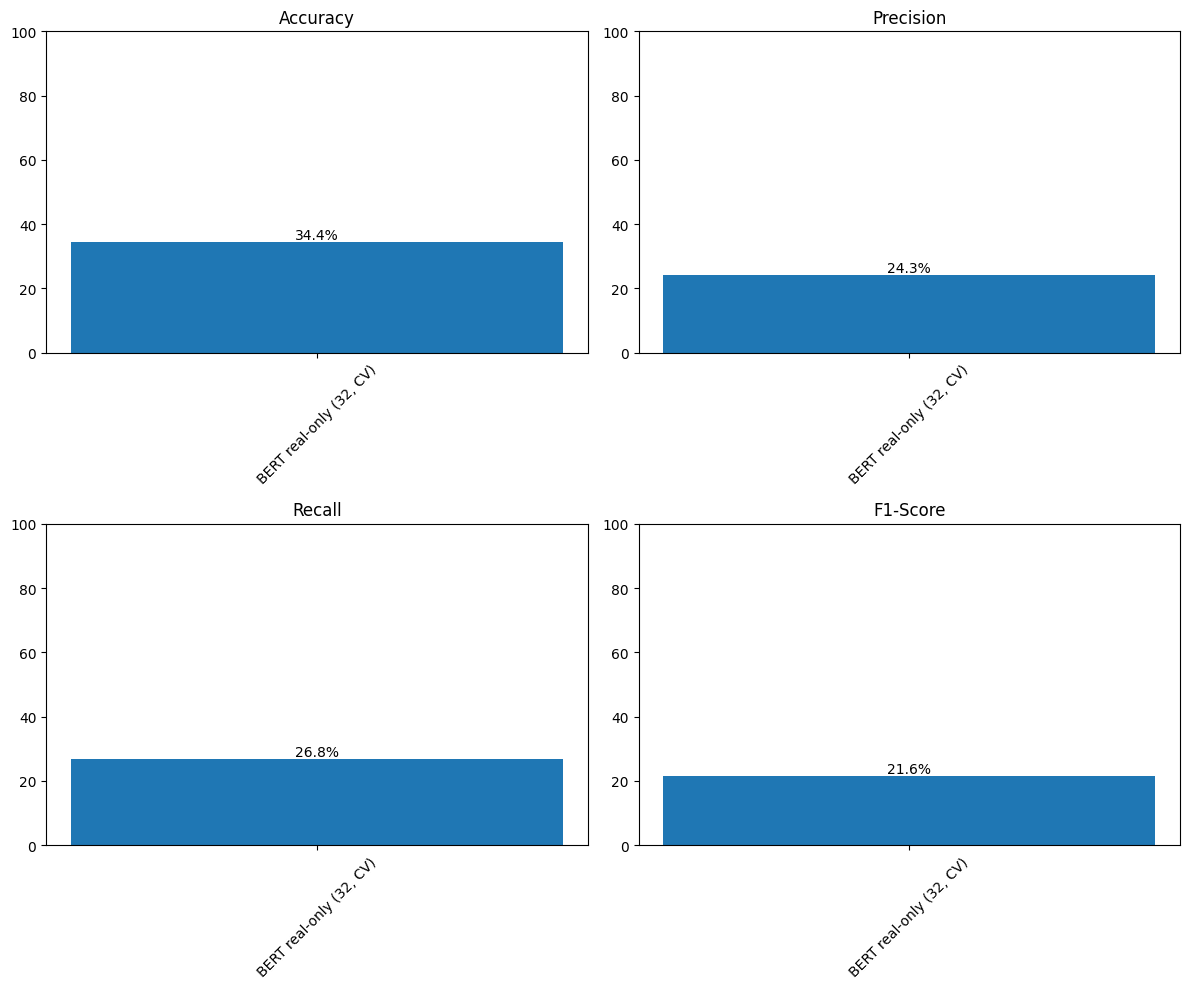

In [4]:
metrics_val.plot()

Under 5 fold CV BERT evaluated on the real labeled examples reached an F1 of 25.3% (Accuracy 37.5, Precision 36.4, Recall 30.3). This is weak but expected for the scale of the data. With approximated 7 examples per class the model cannot represent all five star ratings, so we hypothesize it collapses towards predicting a few classes. This will serve as our low baseline which is exactly the problem b-e attempt to fix by adding more data or different training thechniques.


Moreover, we generate a confusion matrix to evaluate if our hypothesis of collapsing is true. 

In [36]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from Part_2_BERT import train_bert

texts = np.array(texts, dtype=object); labels = np.array(labels)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
yt, yp = [], []
for tr, te in skf.split(texts, labels):
    _, _, p = train_bert(texts[tr].tolist(), labels[tr].tolist(),
                         texts[te].tolist(), labels[te].tolist(),
                         num_train_epochs=10, num_labels=5, early_stopping=False)
    yt += labels[te].tolist(); yp += [int(x) for x in p]



Map:   0%|          | 0/25 [00:00<?, ? examples/s]

Map:   0%|          | 0/7 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/20 [00:00<?, ?it/s]

/Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

/Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 1.43826425075531, 'eval_runtime': 0.0761, 'eval_samples_per_second': 78.842, 'eval_steps_per_second': 13.14, 'epoch': 10.0}
{'train_runtime': 31.5355, 'train_samples_per_second': 8.245, 'train_steps_per_second': 0.634, 'train_loss': 1.083161461353302, 'epoch': 10.0}


/Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/1 [00:00<?, ?it/s]

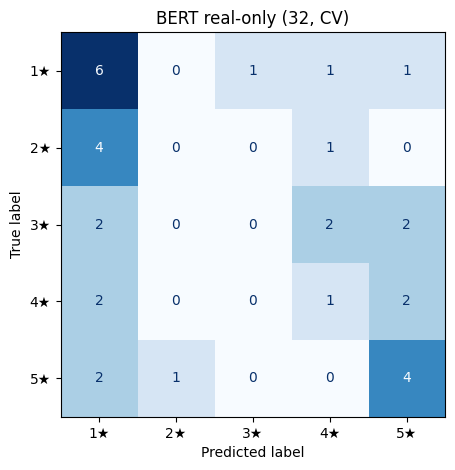

In [37]:
cm = confusion_matrix(yt, yp, labels=[0,1,2,3,4])
ConfusionMatrixDisplay(cm, display_labels=["1★","2★","3★","4★","5★"]).plot(cmap="Blues", colorbar=False)
plt.title("BERT real-only (32, CV)"); plt.tight_layout(); plt.show()

From the confusion matrix we see that the model collapses towards 1 star ratings, since it predicts 1 fro more than half of the examples (18/32) including 4 out of the 5 true 2 star reviews. Meaning, its uisng 1 satar as a default when unable to correctly classify. Moreover, it completely fails on the middle ratings, we have 0 correct calssifications for 2 nad 3 star reviews. Therefore the model only has success at the extremes. 


## Part b:  Data Augmentation

We create templates for reviews and follow a sentence generator (learned from *AI Ethics workshop*) to create synthetic sentences. More specifically, we create reviews from templates (eg "The {aspect} {action}.{detail}) with slots filled form vocabulary, separately for each of our two categories. The key design choice is actions carry a sentiment tier (eg. positive/neutral/negative) and each tier maps to a star range (positive would be 4-5, neutral would be 3 and negative would be 1-2).  So our generated star labeled reviews are derived from the sentiment of the action, not assigned arbitrarily, and the label and the text are coherent by construction.

We first tried a version which mixed sentiments with a single vocabulary which resulted in contradictory reviews. We caught this (cell 16) and decided on a fix. The fix was splitting the vocabularies into sentiment tiers and sampling with a coherence weight scheme:

- 70% from the matching sentiment
- 20% neutral
- 10% form opposite tier to refelect that real reviews aren't purely one sided, for example someone giving a 4 star review but including a flaw.

This methodology makes the reviews more realistic and prevents the model from learning that a star rating  means only positive or only negative words. 

We generate 500 reviews per category with an even rating distribution (0.2 each), so we produce a class balanced augmented dataset, which directly addresses the real data scarcity problem from part a.


#### Evaluation:

We retrain the same BERT from part a, 5 fold CV on real labeled data, with augmented data added only to training never to the test folds. This makes the metric reflect the real label data perfromace nad make sure there's no leakage.





## Setup

In [11]:
#AI assisted code 
from collections import Counter
from typing import Callable, Dict, List, Literal, Tuple
import json
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydantic import BaseModel
from tqdm.auto import tqdm

SEED = 123

# Pydantic models
class Vocabulary(BaseModel):
    name: str          # slot name, e.g. "aspect", "detail"
    words: List[str]


class Action(BaseModel):
    text: str          # verb phrase, e.g. "was absolutely wonderful"
    value: str         # category, e.g. "Travel & Vacation"


class Template(BaseModel):
    text: str          # e.g. "The {aspect} {action}. {detail}."


# Extended model: adds a sentiment tier → star-rating range
class ReviewAction(Action):
    sentiment: Literal["positive", "neutral", "negative"]

    @property
    def star_range(self) -> Tuple[int, int]:
        return {
            "positive": (4, 5),
            "neutral":  (3, 3),
            "negative": (1, 2),
        }[self.sentiment]


## adding sentiment vocabulary 

class SentimentVocabulary(BaseModel):
    """A vocabulary whose words are split by sentiment tier.

    When sampled, the generator picks from the tier that matches the
    review's action sentiment with probability `coherence_weight`,
    from the neutral tier with probability `neutral_weight`, and
    from the opposite tier with probability `contrast_weight`.

    The contrast channel preserves thwarted-expectation reviews
    (e.g. "the room was great… but I would not recommend it") so
    the trained model doesn't learn to look for only pure-positive
    or pure-negative signals.
    """
    name: str
    positive: List[str]
    neutral: List[str]
    negative: List[str]

print("Models loaded.")

Models loaded.


### Review actions

What happened / starts with a verb and categorized into positive, netrual and negative feelings.

In [12]:

travel_actions: List[ReviewAction] = [
    # positive
    ReviewAction(text="was absolutely wonderful",           value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="exceeded all my expectations",      value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="made the whole trip worthwhile",    value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="was spotless and well-maintained",  value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="provided outstanding service",      value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="was a truly memorable experience",  value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="was beautifully organized",         value="Travel & Vacation", sentiment="positive"),
    ReviewAction(text="felt like a dream come true",       value="Travel & Vacation", sentiment="positive"),
    # neutral
    ReviewAction(text="was acceptable but unremarkable",   value="Travel & Vacation", sentiment="neutral"),
    ReviewAction(text="met basic expectations",            value="Travel & Vacation", sentiment="neutral"),
    ReviewAction(text="was decent for the price",          value="Travel & Vacation", sentiment="neutral"),
    ReviewAction(text="was average overall",               value="Travel & Vacation", sentiment="neutral"),
    ReviewAction(text="was nothing special",               value="Travel & Vacation", sentiment="neutral"),
    # negative
    ReviewAction(text="was a complete disappointment",     value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="fell far below expectations",       value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="was dirty and poorly maintained",   value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="ruined the entire vacation",        value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="was overpriced and underwhelming",  value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="was the worst I have ever seen",    value="Travel & Vacation", sentiment="negative"),
    ReviewAction(text="left us stranded without help",     value="Travel & Vacation", sentiment="negative"),
]

media_actions: List[ReviewAction] = [
    # positive
    ReviewAction(text="was an engaging and captivating read",   value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="delivered exceptional storytelling",     value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="offered fresh and insightful content",   value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="was beautifully written and polished",   value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="kept me hooked from start to finish",    value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="was a standout piece of journalism",     value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="provided real depth and nuance",         value="Media & Publishing", sentiment="positive"),
    ReviewAction(text="set a new standard for the genre",       value="Media & Publishing", sentiment="positive"),
    # neutral
    ReviewAction(text="was a standard read with no surprises",  value="Media & Publishing", sentiment="neutral"),
    ReviewAction(text="covered the basics adequately",          value="Media & Publishing", sentiment="neutral"),
    ReviewAction(text="had some interesting parts but dragged", value="Media & Publishing", sentiment="neutral"),
    ReviewAction(text="was forgettable but not terrible",       value="Media & Publishing", sentiment="neutral"),
    ReviewAction(text="neither impressed nor disappointed me",  value="Media & Publishing", sentiment="neutral"),
    # negative
    ReviewAction(text="was riddled with errors and typos",      value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="felt lazy and poorly researched",        value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="was misleading and full of bias",        value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="wasted my time completely",              value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="was the worst publication I have read",  value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="had zero editorial quality",             value="Media & Publishing", sentiment="negative"),
    ReviewAction(text="was clickbait with no real substance",   value="Media & Publishing", sentiment="negative"),
]

all_actions = travel_actions + media_actions

print(f"Travel actions: {len(travel_actions)}  |  Media actions: {len(media_actions)}")
print(f"Total actions:  {len(all_actions)}")

Travel actions: 20  |  Media actions: 20
Total actions:  40


In [13]:
# now create sentence templates using the actions above

travel_templates = [
    Template(text="The {aspect} {action}. {detail}."),
    Template(text="I visited {location} and the {aspect} {action}."),
    Template(text="During our stay, the {aspect} {action}. {recommendation}."),
    Template(text="We booked {qualifier} and the {aspect} {action}."),
    Template(text="After {duration} at {location}, I can say the {aspect} {action}."),
    Template(text="The {aspect} at {location} {action}. {detail}."),
    Template(text="Overall the {aspect} {action}. {qualifier}."),
    Template(text="For a {trip_type} trip, the {aspect} {action}."),
    Template(text="Compared to other places, the {aspect} here {action}. {recommendation}."),
    Template(text="The {aspect} {action}, which really shaped our {trip_type} experience."),
]

media_templates = [
    Template(text="The {media_type} {action}. {detail}."),
    Template(text="I picked up {media_type} by {creator} and it {action}."),
    Template(text="This {media_type} about {topic} {action}. {recommendation}."),
    Template(text="The latest {media_type} from {publisher} {action}."),
    Template(text="After reading the {media_type} on {topic}, I found it {action}. {detail}."),
    Template(text="As a {reader_type}, I think this {media_type} {action}."),
    Template(text="The {media_type} {action}. {qualifier}."),
    Template(text="For anyone interested in {topic}, this {media_type} {action}."),
    Template(text="The editorial quality of the {media_type} {action}. {recommendation}."),
    Template(text="I subscribed for the {topic} coverage and the {media_type} {action}."),
]

print(f"Travel templates: {len(travel_templates)}")
print(f"Media templates:  {len(media_templates)}")

Travel templates: 10
Media templates:  10


In [14]:
# # OLD VOCABULARY (Sentiment MIXED WITHIN VOCAB)

# travel_vocabularies = [
#     Vocabulary(name="aspect", words=[
#         "hotel room", "flight experience", "customer service",
#         "resort amenities", "tour guide", "breakfast buffet",
#         "pool area", "spa treatment", "airport transfer",
#         "beach access", "room service", "check-in process",
#     ]),
#     Vocabulary(name="location", words=[
#         "a seaside resort in Bali", "a boutique hotel in Paris",
#         "a mountain lodge in the Alps", "an all-inclusive in Cancun",
#         "a city hotel in Tokyo", "a safari camp in Kenya",
#         "a countryside B&B in Tuscany", "a cruise ship in the Caribbean",
#     ]),
#     Vocabulary(name="detail", words=[
#         "I would come back in a heartbeat",
#         "The staff went above and beyond",
#         "It was not worth the money at all",
#         "Everything was exactly as advertised",
#         "The photos online were misleading",
#         "We had no complaints whatsoever",
#         "There were several issues during our stay",
#         "The views alone made it worthwhile",
#     ]),
#     Vocabulary(name="recommendation", words=[
#         "Highly recommend for families",
#         "I would not recommend this to anyone",
#         "Great for couples looking for a getaway",
#         "Skip this one and try somewhere else",
#         "Worth every penny for the experience",
#         "Only book this if you have no other options",
#     ]),
#     Vocabulary(name="qualifier", words=[
#         "a last-minute deal online",
#         "through a premium travel agent",
#         "the most expensive package available",
#         "the cheapest option on the site",
#         "a package deal for our anniversary",
#     ]),
#     Vocabulary(name="duration", words=[
#         "a weekend", "five nights", "two weeks", "a full week", "three days",
#     ]),
#     Vocabulary(name="trip_type", words=[
#         "family", "solo", "romantic", "business", "adventure", "budget",
#     ]),
# ]

# # media
# media_vocabularies = [
#     Vocabulary(name="media_type", words=[
#         "magazine", "newspaper", "online journal", "newsletter",
#         "digital edition", "weekly digest", "special report",
#         "anthology", "quarterly review", "podcast transcript",
#     ]),
#     Vocabulary(name="creator", words=[
#         "a well-known columnist", "an independent journalist",
#         "the editorial board", "a first-time author",
#         "a veteran reporter", "a team of investigators",
#     ]),
#     Vocabulary(name="publisher", words=[
#         "a major publishing house", "an indie press",
#         "a university publisher", "an online-only outlet",
#         "a well-established media group", "a nonprofit newsroom",
#     ]),
#     Vocabulary(name="topic", words=[
#         "technology trends", "climate change", "global economics",
#         "cultural history", "modern politics", "health and wellness",
#         "space exploration", "artificial intelligence",
#     ]),
#     Vocabulary(name="detail", words=[
#         "Every paragraph added something new",
#         "The writing quality was surprisingly poor",
#         "I learned a lot from the featured interviews",
#         "It read like an advertisement rather than journalism",
#         "The research behind the piece was impeccable",
#         "I could not get past the first chapter",
#         "The illustrations and layout were top-notch",
#         "There was nothing in it I had not read before",
#     ]),
#     Vocabulary(name="recommendation", words=[
#         "A must-read for anyone in the field",
#         "Save your money and skip this one",
#         "Perfect for a long flight or commute",
#         "Not worth the subscription price",
#         "I have already recommended it to friends",
#         "Only useful as a doorstop",
#     ]),
#     Vocabulary(name="qualifier", words=[
#         "It fills a gap in the market",
#         "There are better alternatives available",
#         "It is a solid choice for beginners",
#         "Seasoned readers will find it lacking",
#         "The price-to-value ratio is fair",
#     ]),
#     Vocabulary(name="reader_type", words=[
#         "regular subscriber", "casual reader", "first-time buyer",
#         "long-time fan of the genre", "professional in the field",
#     ]),
# ]

# for name, vocabs in [("Travel", travel_vocabularies), ("Media", media_vocabularies)]:
#     total_words = sum(len(v.words) for v in vocabs)
#     print(f"{name}: {len(vocabs)} vocabularies, {total_words} total words")

A concern we have is that at the bottom, some of the sentences generated are contradictory. It can be expected that some people can give a good review even if there's something that they didn't like, so don't want to over correct too much, but nervous that if we give the model contradicting sentences, it'll get confused.

At the same time, I think we can make the vocabulary a little better by sentiment WITHOUT having the model learn to only look for purely positive / negative reviews.


In [15]:
## AI assited code below to fix the sentiment alignment

## TRAVEL
# ── Neutral slots (no sentiment) ───────────────────────────────────
travel_neutral_vocabs = [
    Vocabulary(name="aspect", words=[
        "hotel room", "flight experience", "customer service",
        "resort amenities", "tour guide", "breakfast buffet",
        "pool area", "spa treatment", "airport transfer",
        "beach access", "room service", "check-in process",
    ]),
    Vocabulary(name="location", words=[
        "a seaside resort in Bali", "a boutique hotel in Paris",
        "a mountain lodge in the Alps", "an all-inclusive in Cancun",
        "a city hotel in Tokyo", "a safari camp in Kenya",
        "a countryside B&B in Tuscany", "a cruise ship in the Caribbean",
    ]),
    Vocabulary(name="duration", words=[
        "a weekend", "five nights", "two weeks", "a full week", "three days",
    ]),
    Vocabulary(name="trip_type", words=[
        "family", "solo", "romantic", "business", "adventure", "budget",
    ]),
]

# ── Opinion slots (sentiment-split) ────────────────────────────────
travel_sentiment_vocabs = [
    SentimentVocabulary(
        name="detail",
        positive=[
            "I would come back in a heartbeat",
            "The staff went above and beyond",
            "Everything was exactly as advertised",
            "We had no complaints whatsoever",
            "The views alone made it worthwhile",
            "Every detail was thoughtfully arranged",
        ],
        neutral=[
            "It was about what you would expect for the price",
            "Some things were good and others less so",
            "It did the job but nothing stood out",
            "There were both highs and lows during our stay",
        ],
        negative=[
            "It was not worth the money at all",
            "The photos online were misleading",
            "There were several issues during our stay",
            "We could hear noise all night long",
            "The whole place felt neglected",
            "Management did not seem to care",
        ],
    ),
    SentimentVocabulary(
        name="recommendation",
        positive=[
            "Highly recommend for families",
            "Great for couples looking for a getaway",
            "Worth every penny for the experience",
            "Already planning our next visit",
            "I tell everyone about this place",
        ],
        neutral=[
            "It depends on what you are looking for",
            "Might work for a short stay",
            "There are comparable options in the area",
            "Fine if you manage your expectations",
        ],
        negative=[
            "I would not recommend this to anyone",
            "Skip this one and try somewhere else",
            "Only book this if you have no other options",
            "Save your money and look elsewhere",
            "I wish I had read the bad reviews first",
        ],
    ),
    SentimentVocabulary(
        name="qualifier",
        positive=[
            "a premium package and it was worth it",
            "the top-rated option on the site",
            "through a trusted travel agent",
            "a package deal for our anniversary and it delivered",
        ],
        neutral=[
            "a last-minute deal online",
            "a mid-range option after comparing prices",
            "whatever was available on short notice",
        ],
        negative=[
            "the cheapest option and it showed",
            "the most expensive package but it was not worth it",
            "based on fake positive reviews",
            "what was marketed as luxury but clearly was not",
        ],
    ),
]


# MEDIA

# ── Neutral slots ──────────────────────────────────────────────────
media_neutral_vocabs = [
    Vocabulary(name="media_type", words=[
        "magazine", "newspaper", "online journal", "newsletter",
        "digital edition", "weekly digest", "special report",
        "anthology", "quarterly review", "podcast transcript",
    ]),
    Vocabulary(name="creator", words=[
        "a well-known columnist", "an independent journalist",
        "the editorial board", "a first-time author",
        "a veteran reporter", "a team of investigators",
    ]),
    Vocabulary(name="publisher", words=[
        "a major publishing house", "an indie press",
        "a university publisher", "an online-only outlet",
        "a well-established media group", "a nonprofit newsroom",
    ]),
    Vocabulary(name="topic", words=[
        "technology trends", "climate change", "global economics",
        "cultural history", "modern politics", "health and wellness",
        "space exploration", "artificial intelligence",
    ]),
    Vocabulary(name="reader_type", words=[
        "regular subscriber", "casual reader", "first-time buyer",
        "long-time fan of the genre", "professional in the field",
    ]),
]

# ── Opinion slots (sentiment-split) ────────────────────────────────
media_sentiment_vocabs = [
    SentimentVocabulary(
        name="detail",
        positive=[
            "Every paragraph added something new",
            "I learned a lot from the featured interviews",
            "The research behind the piece was impeccable",
            "The illustrations and layout were top-notch",
            "It changed the way I think about the subject",
            "The depth of analysis was remarkable",
        ],
        neutral=[
            "It covered familiar ground competently",
            "Some sections were stronger than others",
            "The writing was serviceable but not memorable",
            "It had a few interesting points buried in filler",
        ],
        negative=[
            "The writing quality was surprisingly poor",
            "It read like an advertisement rather than journalism",
            "I could not get past the first chapter",
            "There was nothing in it I had not read before",
            "The arguments fell apart under any scrutiny",
            "Fact-checking seemed to be an afterthought",
        ],
    ),
    SentimentVocabulary(
        name="recommendation",
        positive=[
            "A must-read for anyone in the field",
            "Perfect for a long flight or commute",
            "I have already recommended it to friends",
            "One of the best things I have read this year",
            "Worth subscribing just for this",
        ],
        neutral=[
            "Read it if you have nothing else on your list",
            "It depends on your level of interest in the topic",
            "Decent enough to skim on a lazy afternoon",
            "Take it or leave it",
        ],
        negative=[
            "Save your money and skip this one",
            "Not worth the subscription price",
            "Only useful as a doorstop",
            "I cancelled my subscription after this",
            "Avoid unless you enjoy being frustrated",
        ],
    ),
    SentimentVocabulary(
        name="qualifier",
        positive=[
            "It fills a gap in the market brilliantly",
            "It is a standout choice for newcomers and experts alike",
            "The price-to-value ratio is excellent",
        ],
        neutral=[
            "It fills a gap in the market",
            "It is a solid choice for beginners",
            "The price-to-value ratio is fair",
        ],
        negative=[
            "There are much better alternatives available",
            "Seasoned readers will find it painfully lacking",
            "It is overpriced for what you actually get",
        ],
    ),
]

for name, nv, sv in [
    ("Travel", travel_neutral_vocabs, travel_sentiment_vocabs),
    ("Media",  media_neutral_vocabs,  media_sentiment_vocabs),
]:
    n_neutral = sum(len(v.words) for v in nv)
    n_sent = sum(len(v.positive) + len(v.neutral) + len(v.negative) for v in sv)
    print(f"{name}: {len(nv)} neutral vocabs ({n_neutral} words) + "
          f"{len(sv)} sentiment vocabs ({n_sent} words)")

Travel: 4 neutral vocabs (31 words) + 3 sentiment vocabs (41 words)
Media: 5 neutral vocabs (35 words) + 3 sentiment vocabs (39 words)


### Generation function

This is building from the code learned in Computational Learning and AI Ethics. 

Also creates the review generation and then from the review generated and the sentiment it has, the function computes a star rating for it.

In [16]:
# pulled from AI Ethics assignment notebook

def capitalize_after_dots(text: str) -> str:
    """Capitalizes the first lowercase letter at the start and after each period."""
    if not text:
        return text
    return re.sub(
        r'((?:^|\.)(?:\s*))([a-z])',
        lambda m: m.group(1) + m.group(2).upper(),
        text,
    )


fixes: List[Callable[[str], str]] = [capitalize_after_dots]

#AI assisted below

# ── Sentiment-tier opposites ───────────────────────────────────────
_OPPOSITE = {"positive": "negative", "negative": "positive", "neutral": "neutral"}


def _pick_from_sentiment_vocab(
    sv: SentimentVocabulary,
    action_sentiment: str,
    rng: random.Random,
    coherence_weight: float = 0.70,
    neutral_weight: float = 0.20,
    contrast_weight: float = 0.10,
) -> str:
    """Sample a word from a SentimentVocabulary, biased toward coherence."""
    tiers = {
        action_sentiment:              (coherence_weight, getattr(sv, action_sentiment)),
        "neutral":                     (neutral_weight,   sv.neutral),
        _OPPOSITE[action_sentiment]:   (contrast_weight,  getattr(sv, _OPPOSITE[action_sentiment])),
    }
    # Deduplicate if action_sentiment == "neutral" (neutral appears twice)
    tier_list = list(tiers.values())
    weights = [t[0] for t in tier_list]
    pools   = [t[1] for t in tier_list]

    # Pick tier, then pick word
    chosen_pool = rng.choices(pools, weights=weights, k=1)[0]
    return rng.choice(chosen_pool)


def generate_reviews(
    templates: List[Template],
    actions: List[ReviewAction],
    neutral_vocabs: List[Vocabulary],
    sentiment_vocabs: List[SentimentVocabulary],
    n_reviews: int = 500,
    rating_weights: Dict[int, float] | None = None,
    coherence_weight: float = 0.70,
    neutral_weight: float = 0.20,
    contrast_weight: float = 0.10,
    seed: int = 42,
) -> List[Dict]:
    """
    Generate synthetic reviews with star ratings and sentiment-coherent slots.

    Adapted from `generate_sentences` in class_notebook.ipynb (cell 15).

    Parameters
    ----------
    templates        : Review sentence patterns with {slot} placeholders.
    actions          : Opinion phrases tagged with category + sentiment.
    neutral_vocabs   : Plain Vocabulary objects for factual slots.
    sentiment_vocabs : SentimentVocabulary objects for opinion slots.
    n_reviews        : Total number of reviews to generate.
    rating_weights   : Desired relative frequency of each star {1: w, …, 5: w}.
    coherence_weight : P(same sentiment) for opinion slots.
    neutral_weight   : P(neutral tier) for opinion slots.
    contrast_weight  : P(opposite sentiment) — thwarted expectations.
    seed             : Reproducibility seed.
    """
    rng = random.Random(seed)

    if rating_weights is None:
        rating_weights = {1: 0.10, 2: 0.10, 3: 0.20, 4: 0.30, 5: 0.30}

    # Index lookups
    neutral_dict = {v.name: v.words for v in neutral_vocabs}
    sentiment_dict = {sv.name: sv for sv in sentiment_vocabs}

    actions_by_sentiment: Dict[str, List[ReviewAction]] = {}
    for a in actions:
        actions_by_sentiment.setdefault(a.sentiment, []).append(a)

    star_to_sentiment = {1: "negative", 2: "negative", 3: "neutral", 4: "positive", 5: "positive"}

    # Pre-compute per-star counts
    stars = list(rating_weights.keys())
    weights = [rating_weights[s] for s in stars]
    total_w = sum(weights)
    counts = {s: int(round(n_reviews * w / total_w)) for s, w in zip(stars, weights)}
    diff = n_reviews - sum(counts.values())
    counts[max(counts, key=lambda s: rating_weights[s])] += diff

    reviews = []

    for star, count in tqdm(counts.items(), desc="Stars", leave=False):
        sentiment = star_to_sentiment[star]
        tier_actions = actions_by_sentiment.get(sentiment, [])
        if not tier_actions:
            continue

        for i in range(count):
            action = rng.choice(tier_actions)
            template = rng.choice(templates)

            chosen_slots = {"action": action.text, "sample_index": i}
            template_slots = set(re.findall(r"{([a-zA-Z_][a-zA-Z0-9_]*)}", template.text))

            for slot_name in template_slots:
                if slot_name in chosen_slots:
                    continue
                # Sentiment-aware slot?
                if slot_name in sentiment_dict:
                    chosen_slots[slot_name] = _pick_from_sentiment_vocab(
                        sentiment_dict[slot_name], sentiment, rng,
                        coherence_weight, neutral_weight, contrast_weight,
                    )
                elif slot_name in neutral_dict:
                    chosen_slots[slot_name] = rng.choice(neutral_dict[slot_name])

            filled_text = template.text.format(**chosen_slots)
            for fix in fixes:
                filled_text = fix(filled_text)

            reviews.append({
                "text": filled_text,
                "category": action.value,
                "star_rating": star,
                "sentiment": sentiment,
                "template": template.text,
                "action": action.text,
                "slots": chosen_slots,
            })

    rng.shuffle(reviews)
    return reviews


print("generate_reviews() defined — with sentiment-coherent slot sampling.")


generate_reviews() defined — with sentiment-coherent slot sampling.


### Create the sentences


In [17]:
RATING_WEIGHTS = {1: 0.20, 2: 0.20, 3: 0.20, 4: 0.20, 5: 0.20} # even distribution
N_PER_CATEGORY = 500

travel_reviews = generate_reviews(
    templates=travel_templates,
    actions=travel_actions,
    neutral_vocabs=travel_neutral_vocabs,
    sentiment_vocabs=travel_sentiment_vocabs,
    n_reviews=N_PER_CATEGORY,
    rating_weights=RATING_WEIGHTS,
    seed=SEED,
)

media_reviews = generate_reviews(
    templates=media_templates,
    actions=media_actions,
    neutral_vocabs=media_neutral_vocabs,
    sentiment_vocabs=media_sentiment_vocabs,
    n_reviews=N_PER_CATEGORY,
    rating_weights=RATING_WEIGHTS,
    seed=SEED,
)

all_reviews = travel_reviews + media_reviews
random.Random(SEED).shuffle(all_reviews)

df_augmented = pd.DataFrame(all_reviews)
df_augmented.drop(columns=["slots"], inplace=True)

print(f"Total generated reviews: {len(df_augmented)}")
print(f"\nCategory distribution:\n{df_augmented['category'].value_counts()}")
print(f"\nStar-rating distribution:\n{df_augmented['star_rating'].value_counts().sort_index()}")
print(f"\nSample reviews:")
df_augmented.head(5)

Stars:   0%|          | 0/5 [00:00<?, ?it/s]

Stars:   0%|          | 0/5 [00:00<?, ?it/s]

Total generated reviews: 1000

Category distribution:
category
Travel & Vacation     500
Media & Publishing    500
Name: count, dtype: int64

Star-rating distribution:
star_rating
1    200
2    200
3    200
4    200
5    200
Name: count, dtype: int64

Sample reviews:


,text,category,star_rating,sentiment,template,action
0,"During our stay, the beach access provided out...",Travel & Vacation,4,positive,"During our stay, the {aspect} {action}. {recom...",provided outstanding service
1,The digital edition was a standard read with n...,Media & Publishing,3,neutral,The {media_type} {action}. {qualifier}.,was a standard read with no surprises
2,The editorial quality of the weekly digest was...,Media & Publishing,4,positive,The editorial quality of the {media_type} {act...,was a standout piece of journalism
3,"Compared to other places, the beach access her...",Travel & Vacation,4,positive,"Compared to other places, the {aspect} here {a...",was a truly memorable experience
4,"Compared to other places, the breakfast buffet...",Travel & Vacation,5,positive,"Compared to other places, the {aspect} here {a...",felt like a dream come true


## check visually that things make sense

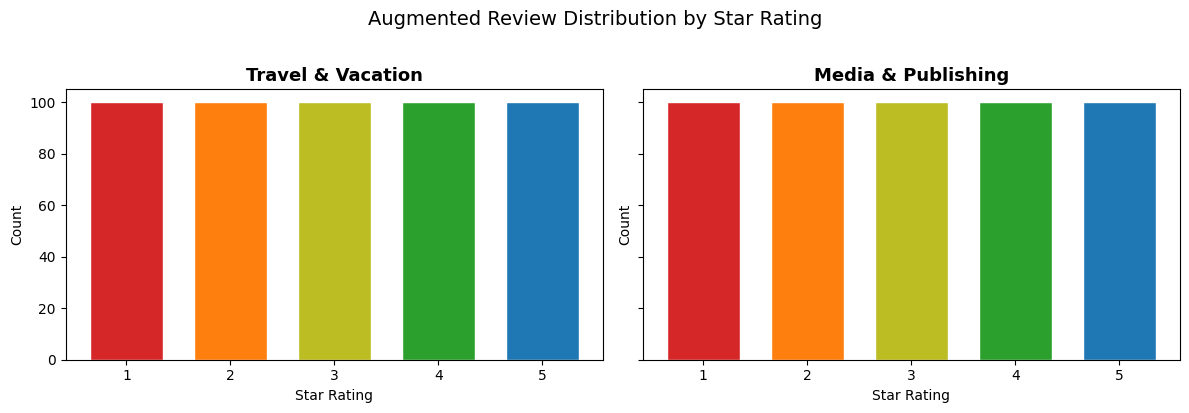

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, cat in zip(axes, ["Travel & Vacation", "Media & Publishing"]):
    subset = df_augmented[df_augmented["category"] == cat]
    counts = subset["star_rating"].value_counts().sort_index()
    colors = ["#D62728", "#FF7F0E", "#BCBD22", "#2CA02C", "#1F77B4"]
    ax.bar(counts.index, counts.values, color=colors, edgecolor="white", width=0.7)
    ax.set_title(cat, fontsize=13, fontweight="bold")
    ax.set_xlabel("Star Rating")
    ax.set_ylabel("Count")
    ax.set_xticks([1, 2, 3, 4, 5])

fig.suptitle("Augmented Review Distribution by Star Rating", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Distribution is the same across, as expected. Also checked the sample sentences and they're more coherent now...and keep a degree of the thwarted expectations aspect that we want to have.

In [19]:

# export_path = os.path.join(root, "data", "augmented_reviews.csv")
# df_augmented.to_csv(export_path, index=False, sep="\t")
# print(f"Saved {len(df_augmented)} reviews to {export_path}")
# print(f"Columns: {list(df_augmented.columns)}")

#### Load 32 labeled examples

In [20]:
import os
import pandas as pd
from utils import preprocess_for_bert

REAL_CSV = os.path.join(root, "data", "filtered_reviews.csv")
df = pd.read_csv(REAL_CSV)
df["review"] = df["review"].apply(preprocess_for_bert)
labeled = df.dropna(subset=["stars", "review"]).reset_index(drop=True)

real_texts = labeled["review"].tolist()
real_labels = (labeled["stars"].astype(int) - 1).tolist()   # 0..4
print(f"Real examples: {len(real_texts)}")

Real examples: 32


#### load augmented data

In [21]:
AUG_CSV = os.path.join(root, "data", "augmented_reviews.csv")
aug_df = pd.read_csv(AUG_CSV, sep="\t")
aug_df["text"] = aug_df["text"].apply(preprocess_for_bert)
aug_df = aug_df.dropna(subset=["text", "star_rating"])

aug_texts = aug_df["text"].tolist()
aug_labels = (aug_df["star_rating"].astype(int) - 1).tolist()   # 0..4
print(f"Augmented examples: {len(aug_texts)}")

Augmented examples: 1000


### Retrain BERT used in part 2a with augmented data




--- Fold 1/5 ---

--- Fold 1 train (25 samples) ---
  Class 1 (28.0%): ███████ (7)
  Class 2 (16.0%): ████ (4)
  Class 3 (20.0%): █████ (5)
  Class 4 (16.0%): ████ (4)
  Class 5 (20.0%): █████ (5)

--- Fold 1 val (7 samples) ---
  Class 1 (28.6%): ██ (2)
  Class 2 (14.3%): █ (1)
  Class 3 (14.3%): █ (1)
  Class 4 (14.3%): █ (1)
  Class 5 (28.6%): ██ (2)


Map:   0%|          | 0/25 [00:00<?, ? examples/s]

Map:   0%|          | 0/7 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 1.6000920534133911, 'eval_runtime': 0.0443, 'eval_samples_per_second': 135.351, 'eval_steps_per_second': 22.559, 'epoch': 6.0}
{'train_runtime': 216.7469, 'train_samples_per_second': 47.336, 'train_steps_per_second': 2.999, 'train_loss': 0.6412120916904547, 'epoch': 6.0}


/Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/1 [00:00<?, ?it/s]


=== BERT_real_augmented_CV K-Fold Results ===
  Accuracy: 53.1%
  Precision: 52.5%
  Recall: 51.4%
  F1-Score: 50.8%
                         Accuracy  Precision  Recall  F1-Score
BERT real-only (32, CV)     34.38      24.29   26.83     21.64
BERT_real_only_CV           34.38      24.29   26.83     21.64
BERT_real_augmented_CV      53.12      52.50   51.40     50.77


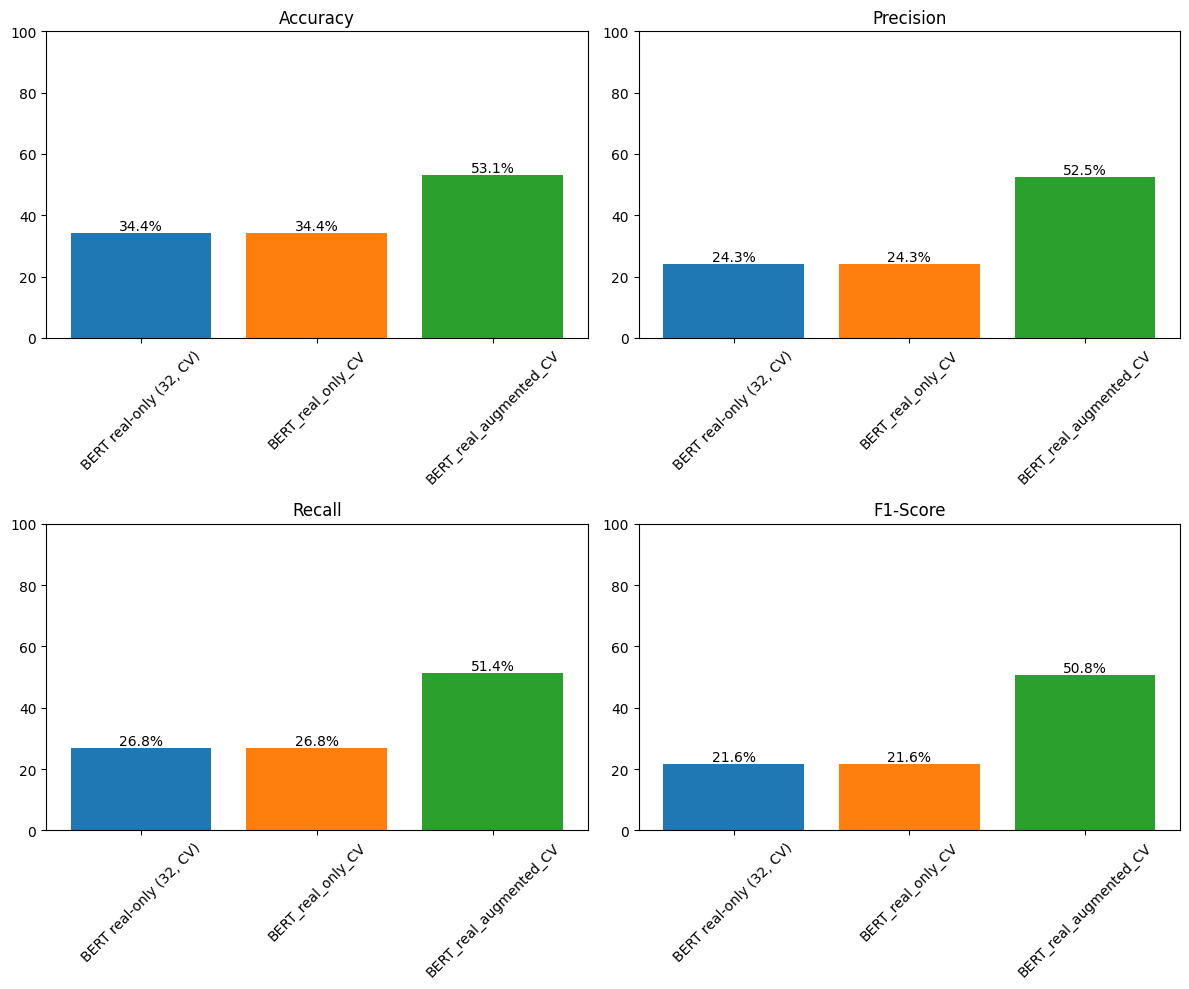

In [24]:
from Part_2_BERT import evaluate_with_kfold, metrics_val
import pandas as pd

# real-only baseline
evaluate_with_kfold(
    real_texts, real_labels,
    n_splits=5, num_labels=5,early_stopping=False,num_train_epochs=10,
    label="BERT_real_only_CV",      
)

# real + augmented
evaluate_with_kfold(
    real_texts, real_labels,
    n_splits=5, num_labels=5,num_train_epochs=10, early_stopping=True,
    label="BERT_real_augmented_CV",   
    extra_texts=aug_texts, extra_labels=aug_labels,
)

print(pd.DataFrame(metrics_val.results).T.round(2))
metrics_val.plot()

# Results

In [26]:
del metrics_val.results["BERT real-only (32, CV)"]   # remove the duplicate
print(pd.DataFrame(metrics_val.results).T.round(2))

                        Accuracy  Precision  Recall  F1-Score
BERT_real_only_CV          34.38      24.29   26.83     21.64
BERT_real_augmented_CV     53.12      52.50   51.40     50.77


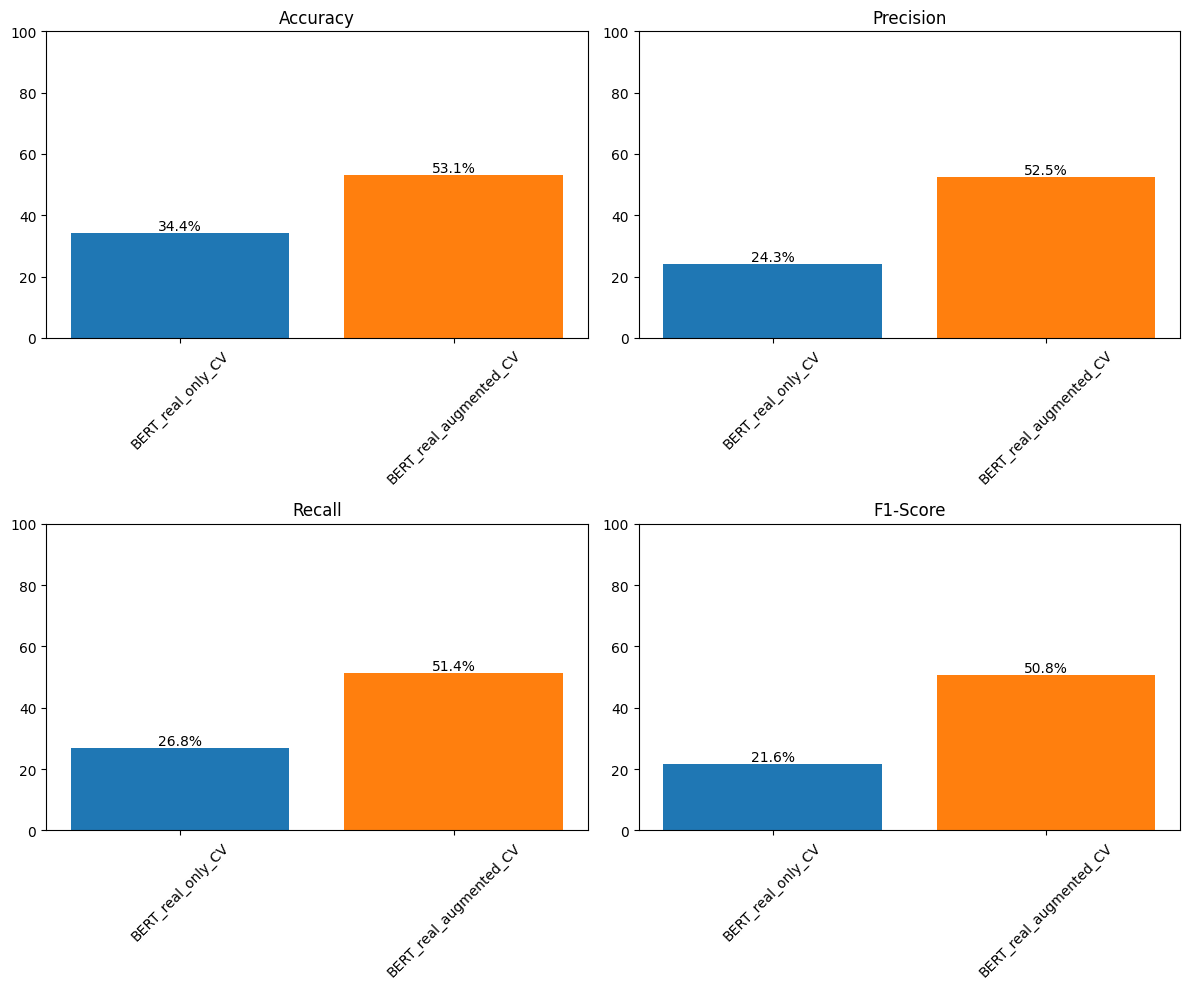

In [27]:
metrics_val.plot()

We can see that the inclusion of the augmented data roughly doubled F1, taking it from 21.6 and lifted accuracy from 34.4 to 53.1. So, this template way of augmenting the data , despite being simple and non LLM based, substantially helped the low data model. We hypothesize the balanced augmented dataset gives the model enough exampels to represent all the five ratings, fixing the collapse to one class we see in the only real data model. 